Cell 1️⃣：基础环境 & 路径设置

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8")
plt.rcParams['font.size'] = 20  # 基础字体大小，所有文字会基于这个值适配，可根据需要调整（如16、18）

Cell 2️⃣：加载一台机器的数据（示例）

In [2]:
DATA_ROOT = Path("../data/raw/ServerMachineDataset")

train_path = DATA_ROOT / "train" / "machine-1-1.txt"
test_path  = DATA_ROOT / "test" / "machine-1-1.txt"
label_path = DATA_ROOT / "test_label" / "machine-1-1.txt"

X_train = np.loadtxt(train_path, delimiter=",")
X_test  = np.loadtxt(test_path, delimiter=",")
y_test  = np.loadtxt(label_path)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Label shape:", y_test.shape)

Train shape: (28479, 38)
Test shape : (28479, 38)
Label shape: (28479,)


“Each machine contains 38 monitoring metrics collected over time.”

Cell 3️⃣：快速检查数据基本统计特征

In [3]:
df = pd.DataFrame(X_train)

summary = df.describe().T[["mean", "std", "min", "max"]]
summary.head()

,mean,std,min,max
0,0.064195,0.056685,0.0,0.494624
1,0.056882,0.042516,0.0,0.421610
2,0.053549,0.037695,0.0,0.278707
3,0.050188,0.037443,0.0,0.250871
4,0.000000,0.000000,0.0,0.000000


Cell 4️⃣：检查零方差 / 低方差指标（非常重要）

In [4]:
std = X_train.std(axis=0)

zero_var_idx = np.where(std < 1e-8)[0]
low_var_idx  = np.where(std < 1e-3)[0]

print(f"Zero-variance metrics: {len(zero_var_idx)}")
print(f"Low-variance metrics (<1e-3): {len(low_var_idx)}")

zero_var_idx, low_var_idx[:10]

Zero-variance metrics: 8
Low-variance metrics (<1e-3): 10


(array([ 4,  7, 16, 17, 26, 28, 36, 37]),
 array([ 4,  7, 16, 17, 26, 28, 32, 33, 36, 37]))

📌 这一格是你之前 warning 的“直接证据”
你在论文 Methodology 里可以合理解释：

“Some metrics remain constant within short temporal windows, which may cause numerical instability in correlation-based modeling.”

Cell 5️⃣：可视化单个指标时间序列

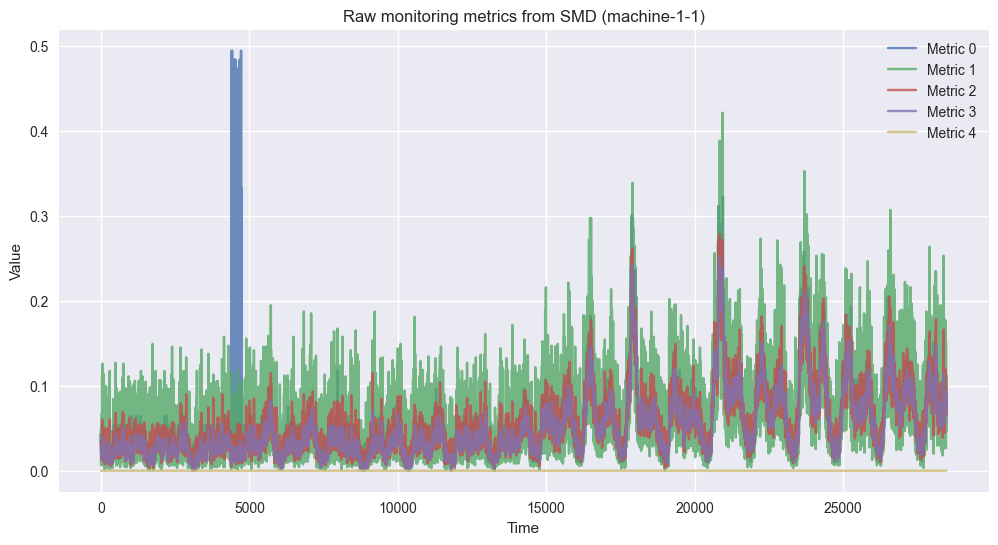

In [5]:
plt.figure(figsize=(12,6))
for i in range(5):
    plt.plot(X_train[:, i], label=f"Metric {i}", alpha=0.8)
plt.legend()
plt.title("Raw monitoring metrics from SMD (machine-1-1)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

Cell 6️⃣：多指标对比（前 5 个）

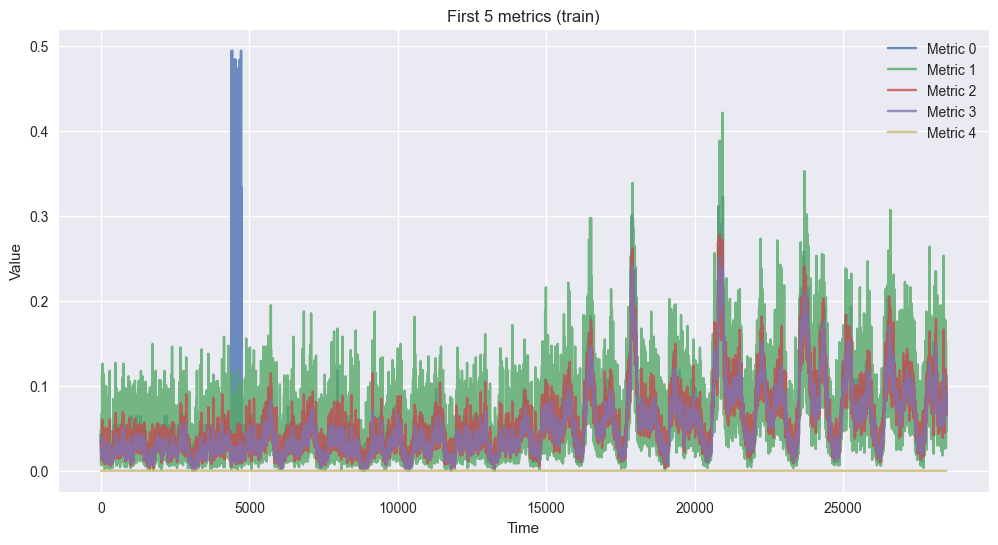

In [6]:
plt.figure(figsize=(12, 6))
for i in range(5):
    plt.plot(X_train[:, i], label=f"Metric {i}", alpha=0.8)

plt.legend()
plt.title("First 5 metrics (train)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

Cell 7️⃣：异常标签可视化（Test 集）

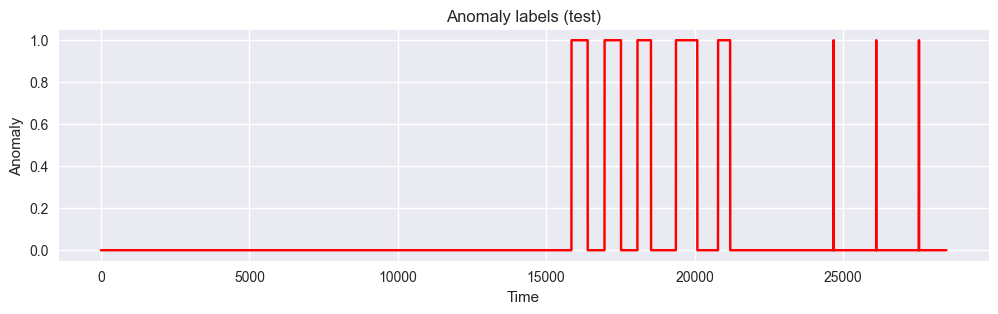

In [7]:
plt.figure(figsize=(12, 3))
plt.plot(y_test, color="red")
plt.title("Anomaly labels (test)")
plt.xlabel("Time")
plt.ylabel("Anomaly")
plt.show()

📌 SMD 特点你可以直接写进论文：
	•	标签是 binary
	•	异常呈 burst / segment 形式
	•	非单点噪声

Cell 8️⃣：滑动窗口示意（与你模型完全一致）

In [8]:
def sliding_window(X, window=10, stride=1):
    return np.stack([X[i:i+window] for i in range(0, len(X)-window, stride)])

W = sliding_window(X_train, window=10)
print("Windowed data shape:", W.shape)

Windowed data shape: (28469, 10, 38)


Cell 9️⃣：窗口内相关性热图（解释“为什么要用超图”）

/opt/homebrew/anaconda3/envs/hgad/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/homebrew/anaconda3/envs/hgad/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


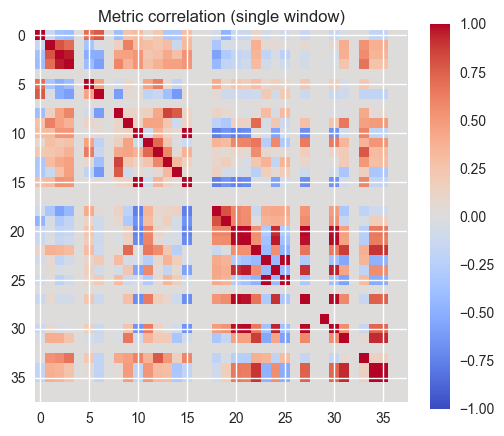

In [9]:
window_id = 0
corr = np.corrcoef(W[window_id].T)
corr = np.nan_to_num(corr)

plt.figure(figsize=(6, 5))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.title("Metric correlation (single window)")
plt.show()

📌 这张图你以后可以截图进论文（Figure 2-x）
用来论证：

“Metrics exhibit strong and dynamic inter-dependencies, motivating hypergraph modeling.”

滑动窗口示意图（证明你做过 preprocessing）

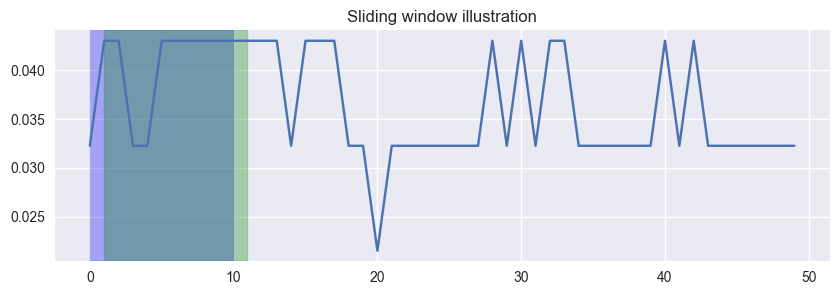

In [10]:
plt.figure(figsize=(10,3))
plt.plot(X_train[:50,0])
plt.axvspan(0,10, alpha=0.3, color='blue')
plt.axvspan(1,11, alpha=0.3, color='green')
plt.title("Sliding window illustration")
plt.show()